In [1]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from scipy.integrate import simpson
import pandas as pd

from feos.eos import EquationOfState, State, Contributions
from feos.pets import PetsParameters
#import si_units as si
import feos.si as si # Use si_units or feos.si depending on package version

import sys
sys.path.append("..")
import LJ_lmft_utils as lmft
import neural_utils as neural
import LJEOS as eos

# Enable or disable Tensor Float 32 Execution
tf.config.experimental.enable_tensor_float_32_execution(False)

2026-01-09 13:33:13.276076: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-09 13:33:13.377267: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767965593.450858   20220 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767965593.463444   20220 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-09 13:33:13.557427: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
def LJ_wall(position, low, high, epsilon=2, sigma=1):
    r_low = position - low
    r_high = high - position
    
    energy_low = 4 * epsilon * ((sigma / r_low)**12 - (sigma / r_low)**6)
    energy_high = 4 * epsilon * ((sigma / r_high)**12 - (sigma / r_high)**6)
    
    return np.where((position >= high) | (position <= low), 1e30, energy_low + energy_high)

    
def get_betaFexc(model_path, zbins, rho_A, rho_B, T, dx=0.005, L=30, rho_b_a = None, rho_b_b = None,
                  eps_AA=1.0, eps_BB=1.0, int_param=0.0, sigma_AA=1.0, sigma_BB=1.0, rc=2.5
                  ):
    """
    Calculate the excess free energy Fexc for a given density profile with functional line integration
    for a long range system using LMFT.

    model: The neural correlation functional
    rho: The density profile
    T: Temperature
    dx: The discretization of the input layer of the model
    L: Length of box
    rc: LJ cutoff
    rho_b: Bulk density to use to calculate mu_R for delta mu.
            If unspecified, assume confined fluid where rho_b is the value at the middle of the density profile.
    """

    model = keras.models.load_model(model_path)

    alphas = np.linspace(0, 1, 100)
    integrands = np.empty_like(alphas)

    if rho_b_a is None:
        rho_b_a = rho_A[int(len(rho_A)/2)] # Taken to be middle of slit

    if rho_b_b is None:
        rho_b_b = rho_B[int(len(rho_B)/2)]

    rho_tot = rho_b_a + rho_b_b
    beta = 1/T

    eps_AB = (1-int_param) * np.sqrt(eps_AA*eps_BB)
    sigma_AB = 0.5 * (sigma_AA + sigma_BB)

    potential_array_AA = lmft.attract(zbins, eps=eps_AA, sig=sigma_AA, cutoff=rc)
    potential_array_AB = lmft.attract(zbins, eps=eps_AB, sig=sigma_AB, cutoff=rc)
    potential_array_BB = lmft.attract(zbins, eps=eps_BB, sig=sigma_BB, cutoff=rc)

    for i, alpha in enumerate(alphas):

        # Calculate delta mu
        c1_sr_b = neural.c1_onetype_T(model, alpha*rho_tot*np.ones_like(rho_A), T*np.ones_like(rho_A), input_bins=1201)
        mu_R_A = np.log(alpha*rho_b_a) - c1_sr_b
        mu_R_B = np.log(alpha*rho_b_b) - c1_sr_b

        if alpha == 0:
            mu_correction_A = np.zeros_like(rho_A)
            mu_correction_B = np.zeros_like(rho_B)

        else:
            try:
                mu_LR = eos.calc_mu_mixture([alpha*rho_b_a, alpha*rho_b_b], T,
                                        np.array([eps_AA, eps_BB]),
                                        np.array([sigma_AA, sigma_BB]),
                                        k_ij = np.array([[0, int_param], [int_param, 0]]),
                                        )
                mu_A = mu_LR[0]
                mu_B = mu_LR[1]
                
                mu_correction_A = mu_A - T*mu_R_A
                mu_correction_B = mu_B - T*mu_R_B

            except RuntimeError as e:
                if "Invalid state in validate: moles = NaN" in str(e):
                    mu_correction_A = np.zeros_like(rho_A)
                    mu_correction_B = np.zeros_like(rho_B)
                else:
                    raise  # Re-raise if it's a different RuntimeError


        mu_correction_A[rho_A == 0] = 0
        mu_correction_B[rho_B == 0] = 0

        V_correction_AA = lmft.V_correction(dx, alpha*(rho_A - rho_b_a), potential_array_AA)
        V_correction_AB = lmft.V_correction(dx, alpha*(rho_B - rho_b_b), potential_array_AB)
        V_correction_BA = lmft.V_correction(dx, alpha*(rho_A - rho_b_a), potential_array_AB)
        V_correction_BB = lmft.V_correction(dx, alpha*(rho_B - rho_b_b), potential_array_BB)

        c1_pred_SR = neural.c1_onetype_T(model, alpha*(rho_A+rho_B), T*np.ones_like(rho_A), input_bins=1201)

        c1_LR_A = c1_pred_SR + beta*(V_correction_AA + V_correction_AB) - beta*mu_correction_A
        c1_LR_B = c1_pred_SR + beta*(V_correction_BB + V_correction_BA) - beta*mu_correction_B

        integrands[i] = np.sum(rho_A * c1_LR_A + rho_B * c1_LR_B) * dx
        
    Fexc = -simpson(integrands, x=alphas)

    return Fexc, c1_LR_A, c1_LR_B


def get_beta_omega(model_path, xbins, rho_A, rho_B, T, mu_A, mu_B, Vext_A, Vext_B, L=30, rho_bulk_A=None, rho_bulk_B = None,
              eps_AA=1.0, eps_BB=1.0, int_param=0.0, sigma_AA=1.0, sigma_BB=1.0, rc=2.5
              ):
    # This is the beta grand potential per unit area

    Fex, c1_LR_A, c1_LR_B = get_betaFexc(model_path, xbins, rho_A, rho_B, T, rho_b_a = rho_bulk_A, rho_b_b = rho_bulk_B,
                                          eps_AA=eps_AA, eps_BB=eps_BB, int_param=int_param,
                                          sigma_AA=sigma_AA, sigma_BB=sigma_BB, rc=rc
                                            )

    valid_A = (rho_A != 0)
    valid_B = (rho_B != 0)

    Fid = (np.trapezoid(rho_A[valid_A] * (np.log(rho_A[valid_A]) - 1), x=xbins[valid_A]) +
             np.trapezoid(rho_B[valid_B] * (np.log(rho_B[valid_B]) - 1), x=xbins[valid_B]) )

    integral = np.trapezoid(rho_A[valid_A] * (Vext_A[valid_A] - mu_A), x=xbins[valid_A]) + np.trapezoid(rho_B[valid_B] * (Vext_B[valid_B] - mu_B), x=xbins[valid_B])

    return Fid + Fex + integral


def pred_gamma(omega, pressure, L):
    return 0.5 * (omega + pressure*L)

In [3]:
def integrate_profile(df, x_min, x_max, column="rho_A"):
    """
    Integrate the density profile between x_min and x_max to get Gamma.
    """
    mask = df["x_centered"].between(x_min, x_max)
    sub = df.loc[mask].sort_values("x_centered")
    return np.trapezoid(sub[column], x=sub["x_centered"])


def compute_H_from_profile(df_rho, rho_bulk, column="rho_B", H_min=None, H_max=None):
    """
    Integrate the density over a range of trial H values and fit Gamma vs H
    to find the H where Gamma = 0.
    """
    if H_min is None:
        H_min = 0.0
    if H_max is None:
        H_max = df_rho["x_centered"].max() - df_rho["x_centered"].min()

    Hrange = np.arange(H_min, H_max, 0.01)
    results = []

    for H in Hrange:
        Gamma = integrate_profile(df_rho, -0.5*H, 0.5*H, column=column) - H*rho_bulk
        results.append((H, Gamma))

    df_ads = pd.DataFrame(results, columns=["H", "Gamma"])

    # Fit linearly near the maximum H to find zero crossing
    df_fit = df_ads.loc[df_ads["H"].between(Hrange[-10], Hrange[-1])]
    coeffs = np.polyfit(df_fit["H"], df_fit["Gamma"], 1)

    H_zero = -coeffs[1] / coeffs[0]
    return H_zero, df_ads

## Extract Thermodynamics from Density Profiles
#### Set up parameters and equation of state

In [4]:
eps_AA = 1.0
eps_BB = 0.9
int_param = 0.15
sigma = np.ones((2))

parameters = PetsParameters.from_lists(sigma = sigma,
                                       epsilon_k = np.array([eps_AA, eps_BB]),
                                       k_ij = np.array([[0, int_param], [int_param, 0]])
                                       )

pets_azeo = EquationOfState.pets(parameters)

In [7]:
mol_frac = np.linspace(0.02, 0.98, num = 25)
#mol_frac = np.linspace(0.63, 0.70, num = 21)
T = 0.77
p = 0.0248

model_path = "../../models/WCA.keras"

width = 1.5
L = 8.0
eps_w = 2.0

#### Extract thermodynamics

In [9]:
S_A = np.empty_like(mol_frac)
S_B = np.empty_like(mol_frac)
rhobar = np.empty_like(mol_frac)
mu_A = np.empty_like(mol_frac)
omega = np.empty_like(mol_frac)
gamma = np.empty_like(mol_frac)
H = np.empty_like(mol_frac)
GammaA = np.empty_like(mol_frac)
GammaB = np.empty_like(mol_frac)

for i, x in enumerate(mol_frac):

    s = State(
        eos=pets_azeo,
        temperature=T*si.KELVIN,
        molefracs = np.array([1-x, x]),
        pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
        )

    rho_tot = s.density * si.NAV * si.ANGSTROM**3
    rhobar[i] = rho_tot
    rho_mixture = rho_tot*np.array([1-x, x])
    betamu = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture)
    mu_A[i] = betamu[0]*T

    file_name = f"../data/results/selectivity/same_eps_w/{x:.4f}/lr_pred_capillary_{L+2*width:.2f}_1.out"
    df = pd.read_csv(file_name, sep= " ")

    xbins = df["xbins"].to_numpy()
    rho_A = df["rho_A"].to_numpy()
    rho_B = df["rho_B"].to_numpy()

    Vext_A = LJ_wall(xbins, width, L+width, eps_w)
    Vext_B = LJ_wall(xbins, width, L+width, eps_w)

    omega[i] = get_beta_omega(model_path, xbins, rho_A, rho_B, T,
                            betamu[0], betamu[1], Vext_A, Vext_B, L,
                            rho_bulk_A = rho_mixture[0], rho_bulk_B = rho_mixture[1],
                            eps_AA=eps_AA, eps_BB=eps_BB, int_param=int_param)

    N_A = np.trapezoid(rho_A, x=xbins) / L
    N_B = np.trapezoid(rho_B, x=xbins) / L
    N_tot = N_A + N_B

    x_A_slit = N_A/N_tot
    x_B_slit = N_B/N_tot

    S_A[i] = x_A_slit / (1 - x)
    S_B[i] = x_B_slit / x

    gamma[i] = pred_gamma(T*omega[i], p, L)

    df_rho = df
    df_rho["x_centered"] = df_rho["xbins"] - df_rho["xbins"].mean()
    ## Get H from GammaB = 0
    H[i], _ = compute_H_from_profile(df_rho, rho_mixture[1], column="rho_B", H_min=L-6, H_max=L+10)
    GammaA[i] = integrate_profile(df_rho, -0.5*H[i], 0.5*H[i], column="rho_A") - H[i]*rho_mixture[0]
    GammaB[i] = integrate_profile(df_rho, -0.5*H[i], 0.5*H[i], column="rho_B") - H[i]*rho_mixture[1]


/tmp/ipykernel_20220/3569459639.py:53: RuntimeWarning: divide by zero encountered in log
  mu_R_A = np.log(alpha*rho_b_a) - c1_sr_b
/tmp/ipykernel_20220/3569459639.py:54: RuntimeWarning: divide by zero encountered in log
  mu_R_B = np.log(alpha*rho_b_b) - c1_sr_b
/tmp/ipykernel_20220/3569459639.py:53: RuntimeWarning: divide by zero encountered in log
  mu_R_A = np.log(alpha*rho_b_a) - c1_sr_b
/tmp/ipykernel_20220/3569459639.py:54: RuntimeWarning: divide by zero encountered in log
  mu_R_B = np.log(alpha*rho_b_b) - c1_sr_b
/tmp/ipykernel_20220/3569459639.py:53: RuntimeWarning: divide by zero encountered in log
  mu_R_A = np.log(alpha*rho_b_a) - c1_sr_b
/tmp/ipykernel_20220/3569459639.py:54: RuntimeWarning: divide by zero encountered in log
  mu_R_B = np.log(alpha*rho_b_b) - c1_sr_b
/tmp/ipykernel_20220/3569459639.py:53: RuntimeWarning: divide by zero encountered in log
  mu_R_A = np.log(alpha*rho_b_a) - c1_sr_b
/tmp/ipykernel_20220/3569459639.py:54: RuntimeWarning: divide by zero encoun

In [76]:

np.savetxt("../data/results/selectivity/same_eps_w/thermodynamics.dat",
           np.c_[mol_frac, rhobar, mu_A, S_A, S_B, omega, gamma, H, GammaA],
            delimiter=" ",
            header="xB rhobar mu_A S_A S_B omega gamma H GammaA",
            comments="",
            fmt=['%.2f', '%.20f', '%.20f', '%.20f', '%.20f', '%.20f', '%.20f', '%.20f', '%.20f'])


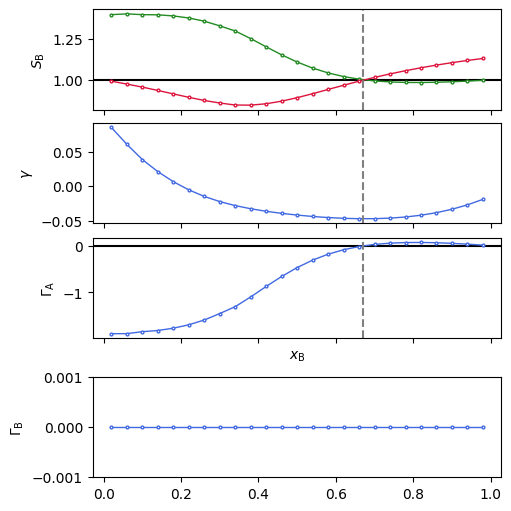

In [10]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(5, 5), sharex=True, layout="constrained")

axs[0].plot(mol_frac, S_B, '-o', markersize=2, color="forestgreen", lw=1, markerfacecolor="white")
axs[0].plot(mol_frac, S_A, '-o', markersize=2, color="crimson", lw=1, markerfacecolor="white")

axs[1].plot(mol_frac, gamma, '-o', markersize=2, color="royalblue", lw=1, markerfacecolor="white")
axs[2].plot(mol_frac, GammaA, '-o', markersize=2, color="royalblue", lw=1, markerfacecolor="white")
axs[3].plot(mol_frac, GammaB, '-o', markersize=2, color="royalblue", lw=1, markerfacecolor="white")

axs[3].set_ylim(-0.001, 0.001)

for i in range(3):
    axs[i].axvline(0.67, color="grey", linestyle="dashed")

axs[0].axhline(1.0, color="black", zorder=0)
axs[2].axhline(0.0, color="black", zorder=0)

axs[0].set_ylabel(r"$ S_{\text{B}}$")
axs[1].set_ylabel(r"$ \gamma$")
axs[2].set_ylabel(r"$ \Gamma_{\text{A}}$")
axs[3].set_ylabel(r"$ \Gamma_{\text{B}}$")

axs[2].set_xlabel(r"$x_{\text{B}}$") 

#plt.savefig("../../data/capillary/selectivity.png", bbox_inches="tight", pad_inches=0.01)
plt.show()


## Calculate predictions from theory
We expect these to fit well around $x^{\text{(az)}}$. $H$ is chosen such that $\Gamma_{\text{B}} = 0$. Note that for some states (e.g. low $ϵ_w$) that $\Gamma_{\text{B}} = 0$ does not exist.

In [11]:
def pred_S(GammaA, H, rhobar):

    #S_B = 1 / (1 + GammaA/(H*rhobar)) # Should be valid for all GammaA
    S_B = 1 - GammaA/(H*rhobar) # Linearised form valid for small GammaA

    return S_B


def pred_dSdx(mol_frac, GammaA_list, H_list, rhobar_list):

    dGammaA_dxB = np.gradient(GammaA_list, mol_frac)
    drhobar_dxB = np.gradient(rhobar_list, mol_frac)

    dSdx = (-1/(H_list*rhobar_list)) * dGammaA_dxB + ((1*GammaA_list)/(H_list*rhobar_list**2))*drhobar_dxB

    return dSdx


def pred_dgammadx(mol_frac, GammaA_list, mu_A_list):

    dmuA_dxB = np.gradient(mu_A_list, mol_frac)
    dgamma_dx = (-GammaA_list/2) * dmuA_dxB

    dxB_muA = np.gradient(mol_frac, mu_A_list)
    dgamma_dx = (-GammaA_list/2) / dxB_muA

    return dgamma_dx

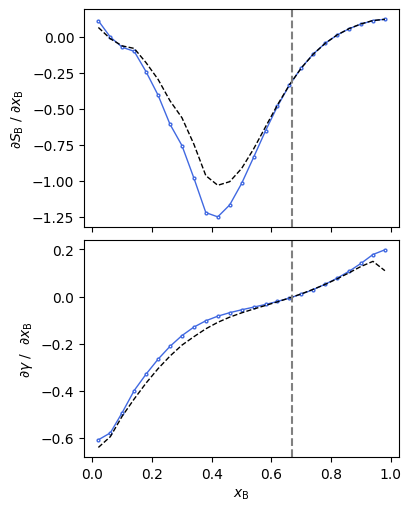

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(4, 5), sharex=True, layout="constrained")

axs[0].plot(mol_frac, np.gradient(S_B, mol_frac), '-o', markersize=2, color="royalblue", lw=1, markerfacecolor="white")
axs[0].plot(mol_frac, pred_dSdx(mol_frac, GammaA, H, rhobar), markersize=2, color="black", lw=1, linestyle="dashed")

axs[1].plot(mol_frac, np.gradient(gamma, mol_frac), '-o', markersize=2, color="royalblue", lw=1, markerfacecolor="white")
axs[1].plot(mol_frac, pred_dgammadx(mol_frac, GammaA, mu_A), markersize=2, color="black", lw=1, linestyle="dashed")

for i in range(2):
    axs[i].axvline(0.67, color="grey", linestyle="dashed")


axs[0].set_ylabel(r"$ \partial{S_{\text{B}}}$ / $\partial{x_{\text{B}}}$")
axs[1].set_ylabel(r"$ \partial{\gamma}$ /  $\partial{x_{\text{B}}}$")

axs[1].set_xlabel(r"$x_{\text{B}}$")

#plt.savefig("../../data/capillary/selectivity_derivatives.png", bbox_inches="tight", pad_inches=0.01)
plt.show()
